# Analysis

In [2]:
module_path = '/data/ascaffid/LHC_Olympics/EagleEye/eagleeye'
import sys
sys.path.append(module_path)
import EagleEye
from utils_EE import compute_the_null, partitioning_function
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import random

import pandas as pd

import astropy
import astropy.table as at

from astropy.io import ascii
from astropy.table import Table

import matplotlib.cm as cm


from astropy.io.votable import parse, parse_single_table

from astropy.coordinates import SkyCoord
from dustmaps.planck import PlanckQuery
from dustmaps.sfd import SFDQuery
import astropy.units as units
import sklearn

import time
from astroquery.gaia import Gaia

/scratch/ascaffid/anaconda3/envs/lhc/lib/python3.9/site-packages/dustmaps/config.py:74: ConfigWarning: Configuration file not found:

    /u/a/ascaffid/.dustmapsrc

To create a new configuration file in the default location, run the following python code:

    from dustmaps.config import config
    config.reset()

Note that this will delete your configuration! For example, if you have specified a data directory, then dustmaps will forget about its location.
  warn(('Configuration file not found:\n\n'


The archive is unstable and may perform below expectations. Please avoid launching intense Python query showers. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the recent infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


# Toy data

In [3]:
import numpy as np

def make_gaussian_multi_ref_background(
    nY=2000,
    nX_each=2000,
    n_refs=8,
    d=4,
    mean=None,
    cov=None,
    seed=42,
):
    """
    Generate Y and X_refs from the SAME d-dimensional Gaussian.
    """
    rng = np.random.default_rng(seed)

    if mean is None:
        mean = np.zeros(d)
    if cov is None:
        cov = np.eye(d)

    Y = rng.multivariate_normal(mean, cov, size=nY).astype(float)
    X_refs = [
        rng.multivariate_normal(mean, cov, size=nX_each).astype(float)
        for _ in range(n_refs)
    ]

    return X_refs, Y


# Example
X_refs, Y = make_gaussian_multi_ref_background(
    nY=20000,
    nX_each=20000,
    n_refs=8,
    d=4,
    seed=42,
)

## EagleEye

In [4]:
import numpy as np
from concurrent.futures import ProcessPoolExecutor, as_completed

def _compute_the_null_worker(args):
    """
    Top-level worker so it is picklable.
    """
    j, p_j, K_M, N = args
    from utils_EE import compute_the_null  # import inside worker for subprocess
    stats_null_j = compute_the_null(p=p_j, K_M=K_M, N=N)
    return j, float(p_j), stats_null_j


def compute_the_null_multi_refs(p_list, K_M, N=500_000, n_jobs=8):
    """
    Parallel multi-reference wrapper around utils_EE.compute_the_null.

    Parameters
    ----------
    p_list : list[float]
        p_j = n_Y/(n_Y+n_Xj) per reference.
    K_M : int
    N : int
    n_jobs : int

    Returns
    -------
    stats_null_multi : dict
      {
        "p_list": [...],
        "K_M": K_M,
        "N": N,
        "by_ref": {
            j: {"p": p_j, "stats_null": {...}},
            ...
        }
      }
    """
    p_list = list(map(float, p_list))
    tasks = [(j, p_j, int(K_M), int(N)) for j, p_j in enumerate(p_list)]

    by_ref = {}
    max_workers = min(int(n_jobs), len(tasks)) if tasks else 1

    with ProcessPoolExecutor(max_workers=max_workers) as ex:
        futures = [ex.submit(_compute_the_null_worker, t) for t in tasks]
        for fut in as_completed(futures):
            j, p_j, stats_null_j = fut.result()
            by_ref[j] = {"p": p_j, "stats_null": stats_null_j}

    return {"p_list": p_list, "K_M": K_M, "N": N, "by_ref": by_ref}




In [ ]:
p_list = [len(Y) / (len(Y) + len(Xj)) for Xj in X_refs]
kM = 300 # Keep about 10% of size of ref ant test ~400 for candidate 1
p_ext = 1E-5

stats_null_multi = compute_the_null_multi_refs(
    p_list=p_list,
    K_M=kM,
    N=200000,
    n_jobs=8
)


In [ ]:
upsilonsS = []
for j, p_j in enumerate(p_list):
    null_array_j = stats_null_multi["by_ref"][j]["stats_null"][p_j]
    
    Gamma_star_j = np.quantile(
        null_array_j,
        1 - p_ext,
        method="higher"
    )
    upsilonsS.append(Gamma_star_j)
    print(f"Reference {j}: Gamma_star_j = {Gamma_star_j}")


Reference 0: Gamma_star_j = 13.64262548694883
Reference 1: Gamma_star_j = 13.64262548694883
Reference 2: Gamma_star_j = 13.64262548694883
Reference 3: Gamma_star_j = 13.64262548694883
Reference 4: Gamma_star_j = 13.64262548694883
Reference 5: Gamma_star_j = 13.64262548694883
Reference 6: Gamma_star_j = 13.64262548694883
Reference 7: Gamma_star_j = 13.64262548694883


In [ ]:
import numpy as np
import EagleEye
from utils_EE import partitioning_function
from EagleEye import S_rootB_estimate_Y_overdensities, B_estimate_Y_overdensities

def compute_Gamma_i_multi_ref_with_SrootB(
    X_refs, Y,
    stats_null_multi,
    K_M=500,
    p_ext=1e-5,
    n_jobs=8,
    Z=2.65,
    upsilon_key="Upsilon_i_Y",
):
    R = len(X_refs)
    nY = len(Y)

    Upsilon_by_ref = np.zeros((R, nY), float)
    result_dicts   = []
    EE_books       = []
    SrootB_by_ref  = []
    B_by_ref       = []   # <-- NEW

    for j, Xj in enumerate(X_refs):
        stats_null_j = stats_null_multi["by_ref"][j]["stats_null"]

        # 1) Soar
        rd, _ = EagleEye.Soar(
            Xj, Y,
            K_M=K_M,
            p_ext=p_ext,
            n_jobs=n_jobs,
            stats_null=stats_null_j,
            result_dict_in={},
            do_IDE=True
        )

        if upsilon_key not in rd:
            raise KeyError(f"Ref {j}: missing '{upsilon_key}'. Keys: {list(rd.keys())}")

        ups = np.asarray(rd[upsilon_key], float)
        if ups.shape != (nY,):
            raise ValueError(f"Ref {j}: {upsilon_key} shape {ups.shape}, expected {(nY,)}")

        Upsilon_by_ref[j] = ups
        result_dicts.append(rd)

        # 2) Cluster
        clusters = partitioning_function(Xj, Y, rd, p_ext=p_ext, Z=Z)

        # 3) Repechage
        EE_book = EagleEye.Repechage(Xj, Y, rd, clusters, p_ext=p_ext)
        EE_books.append(EE_book)

        # 4a) s/sqrt(B)
        srb = S_rootB_estimate_Y_overdensities(rd, EE_book)
        SrootB_by_ref.append(srb)

        # 4b) B-hat (your new function)
        bhat = B_estimate_Y_overdensities(rd, EE_book)
        B_by_ref.append(bhat)

        # ---- Print cluster sizes + s/sqrt(B) + B-hat ----
        over_clusters = EE_book.get("Y_OVER_clusters", {})
        if isinstance(over_clusters, dict) and len(over_clusters) > 0:
            print(f"[ref {j}] Y_OVER_clusters: {len(over_clusters)}")
            for cid in sorted(over_clusters.keys()):
                rep = np.asarray(over_clusters[cid].get("Repechaged", []), dtype=int)
                bg  = np.asarray(over_clusters[cid].get("Background", []), dtype=int)
                pr  = np.asarray(over_clusters[cid].get("Pruned", []), dtype=int)

                srootb_c = srb.get("s/root(B)", {}).get(cid, np.nan)
                Bhat_c   = bhat.get("B", {}).get(cid, np.nan)
                ups_min  = srb.get("Upsilon_alpha_plus", {}).get(cid, np.nan)

                print(
                    f"  cluster {cid}: "
                    f"|Rep|={rep.size:4d}, |Bg|={bg.size:4d}, |Pr|={pr.size:4d} "
                    f" -> B̂={Bhat_c:.2f}, s/√B={srootb_c:.3f}, min(Upsilon)={ups_min:.3f}"
                )
        else:
            print(f"[ref {j}] Y_OVER_clusters: 0")

        print(f"[ref {j}] Total: "
              f"B̂={bhat.get('B', {}).get('Total', np.nan):.2f}, "
              f"s/√B={srb.get('s/root(B)', {}).get('Total', np.nan):.3f}")

    Gamma_i = np.sum(Upsilon_by_ref, axis=0)

    return {
        "Gamma_i": Gamma_i,
        "Upsilon_by_ref": Upsilon_by_ref,
        "result_dicts": result_dicts,
        "EE_books": EE_books,
        "SrootB_by_ref": SrootB_by_ref,
        "B_by_ref": B_by_ref,          # <-- NEW
        "p_ext": p_ext,
        "K_M": K_M,
        "Z": Z,
        "upsilon_key": upsilon_key,
    }


# Example call
out = compute_Gamma_i_multi_ref_with_SrootB(
    X_refs=X_refs,
    Y=Y,
    stats_null_multi=stats_null_multi,
    K_M=kM,
    p_ext=p_ext,
    n_jobs=100,
    Z=2.65,
    upsilon_key="Upsilon_i_Y"
)

Gamma_i        = out["Gamma_i"]
B_by_ref       = out["B_by_ref"]
SrootB_by_ref  = out["SrootB_by_ref"]
EE_books       = out["EE_books"]
result_dicts   = out["result_dicts"]

-----------------------------------------------------------------
Eagle...Soar!
-----------------------------------------------------------------
Compute the nearest neighbours
KNN completed: 0.00 %
KNN completed: 25.00 %
KNN completed: 50.00 %
KNN completed: 75.00 %
-----------------------------------------------------------------
Flagging of putative anomalous points
-----------------------------------------------------------------


<IPython.core.display.Math object>

'DONE!'

<IPython.core.display.Math object>

'DONE!'

...

-----------------------------------------------------------------
Clustering
-----------------------------------------------------------------
-----------------------------------------------------------------
Repêchage
-----------------------------------------------------------------


'!!! No Y-Overdensities found !!!'

'!!! No X-Overdensities found !!!'

[ref 7] Y_OVER_clusters: 1
  cluster 0: |Rep|=   0, |Bg|=   0, |Pr|=   0  -> B̂=nan, s/√B=nan, min(Upsilon)=nan
[ref 7] Total: B̂=0.00, s/√B=nan


/data/ascaffid/LHC_Olympics/EagleEye/eagleeye/EagleEye.py:698: RuntimeWarning: invalid value encountered in scalar divide
  S_B = S_B / np.sqrt((lenBo *  (n2 - lenWo)/ (n1 - lenWu)))


In [ ]:
# Bootstrat emperical null
import numpy as np

def bootstrap_gamma_null_uniform(
    X_refs, Y,
    stats_null_multi,
    K_M=kM,
    p_ext=p_ext,
    n_jobs=100,
    upsilon_key="Upsilon_i_Y",
    n_boot=50,
    seed=0,
):
    """
    Bootstrap an empirical null for Gamma_i by rerunning your *exact* multi-ref pipeline
    on Uniform([0,1]^d) vs Uniform([0,1]^d), matching the cardinalities of your real data.

    For each bootstrap b:
      - Generate Yb ~ Unif([0,1]^d) with len(Y) points
      - Generate each Xb_j ~ Unif([0,1]^d) with len(X_refs[j]) points
      - Call compute_Gamma_i_multi_ref(...) using the *same* stats_null_multi
      - Store Gamma_i^(b)

    Returns
    -------
    Gamma_null : np.ndarray, shape (n_boot, len(Y))
        Empirical null draws of the full pointwise Gamma_i vector.
    """
    rng = np.random.default_rng(seed)

    n_refs = len(X_refs)
    nY = len(Y)
    d = Y.shape[1]

    nX_list = [Xj.shape[0] for Xj in X_refs]

    Gamma_null = np.zeros((n_boot, nY), dtype=float)

    for b in range(n_boot):
        # generate null data with same cardinalities and same feature dimension
        Yb = rng.random((nY, d)).astype(float)
        Xb_refs = [rng.random((nX, d)).astype(float) for nX in nX_list]

        Gamma_b = compute_Gamma_i_multi_ref_with_SrootB(
            X_refs=Xb_refs,
            Y=Yb,
            stats_null_multi=stats_null_multi,
            K_M=K_M,
            p_ext=p_ext,
            n_jobs=n_jobs,
            upsilon_key=upsilon_key,
        )

        Gamma_null[b] = Gamma_b['Gamma_i']

        if (b + 1) % max(1, n_boot // 10) == 0:
            print(f"bootstrap {b+1}/{n_boot} done")

    return Gamma_null


def flatten_gamma_null(Gamma_null, finite_only=True):
    """
    Convenience: flatten bootstraps into one long 1D sample for quantiles/histograms.
    """
    g = Gamma_null.reshape(-1)
    if finite_only:
        g = g[np.isfinite(g)]
    return g


# -------------------------
# Example usage
# -------------------------
Gamma_null_mat = bootstrap_gamma_null_uniform(
    X_refs=X_refs, Y=Y,
    stats_null_multi=stats_null_multi,
    K_M=kM, p_ext=p_ext, n_jobs=100,
    upsilon_key="Upsilon_i_Y",
    n_boot=1,
    seed=42,
)



-----------------------------------------------------------------
Eagle...Soar!
-----------------------------------------------------------------
Compute the nearest neighbours
KNN completed: 0.00 %
KNN completed: 25.00 %
KNN completed: 50.00 %
KNN completed: 75.00 %
-----------------------------------------------------------------
Flagging of putative anomalous points
-----------------------------------------------------------------


<IPython.core.display.Math object>

'DONE!'

<IPython.core.display.Math object>

'DONE!'

...

<IPython.core.display.Math object>

alpha = 1


'DONE!'

[ref 7] Y_OVER_clusters: 1
  cluster 0: |Rep|=   0, |Bg|=   0, |Pr|=   0  -> B̂=nan, s/√B=nan, min(Upsilon)=nan
[ref 7] Total: B̂=0.00, s/√B=nan
bootstrap 1/1 done


/data/ascaffid/LHC_Olympics/EagleEye/eagleeye/EagleEye.py:698: RuntimeWarning: invalid value encountered in scalar divide
  S_B = S_B / np.sqrt((lenBo *  (n2 - lenWo)/ (n1 - lenWu)))


In [ ]:
import numpy as np
import numpy as np



def _pruned_dict_to_mask(pruned_dict, nY):
    mask = np.zeros(nY, dtype=bool)
    if pruned_dict is None:
        return mask

    if isinstance(pruned_dict, dict):
        if len(pruned_dict) == 0:
            return mask
        idxs = []
        for v in pruned_dict.values():
            if v is None:
                continue
            idxs.extend(list(v))
        if len(idxs) == 0:
            return mask
        idxs = np.asarray(idxs, dtype=int)
        idxs = idxs[(idxs >= 0) & (idxs < nY)]
        mask[idxs] = True
        return mask

    idxs = np.asarray(list(pruned_dict), dtype=int)
    if idxs.size == 0:
        return mask
    idxs = idxs[(idxs >= 0) & (idxs < nY)]
    mask[idxs] = True
    return mask


def combine_multi_ref_pruning(
    result_dicts,
    nY,
    p_ext=1e-5,
    upsilon_key="Upsilon_i_Y",
    pruned_key="Y_Pruned",
    ide_key="Y_IDE",
    # --- NEW: persistence definition ---
    persistence_mode="tilde_nonzero",   # "tilde_nonzero" | "survive_mask" | "tilde_above_ustar"
    treat_pruned_as_removed=True,
):
    """
    Combine multi-reference results after per-reference IDE/pruning has already run.

    Computes:
      - Gamma_raw: sum_j Upsilon_i^(j)
      - Gamma_tilde (aka Gamma_pruned): sum_j Upsilon_i^(j) * S_i^(j)  where S is survival
      - persistence: by default counts refs contributing nonzero to Gamma_tilde

    persistence_mode options
    ------------------------
    "tilde_nonzero":
        persistence_i = #{j : Upsilon_i^(j) * S_i^(j) > 0}
        (this is the most literal "persistence by surviving tilde gamma")

    "survive_mask":
        persistence_i = #{j : S_i^(j) == 1}
        (counts refs where i was not pruned, regardless of score magnitude)

    "tilde_above_ustar":
        persistence_i = #{j : Upsilon_i^(j) * S_i^(j) > Ustar_j}
        (counts refs where i remains significant after pruning)
    """
    R = len(result_dicts)
    Upsilon_by_ref = np.zeros((R, nY), dtype=float)
    pruned_masks = np.zeros((R, nY), dtype=bool)
    Ustar_by_ref = np.full(R, np.nan, dtype=float)

    # --- ingest per-ref arrays and pruning info ---
    for j, rd in enumerate(result_dicts):
        if upsilon_key not in rd:
            raise KeyError(f"Ref {j}: missing '{upsilon_key}'. Keys: {list(rd.keys())}")

        ups = np.asarray(rd[upsilon_key], dtype=float)
        if ups.shape[0] != nY:
            raise ValueError(f"Ref {j}: {upsilon_key} has shape {ups.shape}, expected ({nY},)")

        Upsilon_by_ref[j] = ups

        if "Upsilon_star_plus" in rd and isinstance(rd["Upsilon_star_plus"], dict) and p_ext in rd["Upsilon_star_plus"]:
            Ustar_by_ref[j] = float(rd["Upsilon_star_plus"][p_ext])

        pruned_obj = rd.get(pruned_key, None)
        if pruned_obj is None or (isinstance(pruned_obj, dict) and len(pruned_obj) == 0):
            pruned_obj = rd.get(ide_key, None)

        pruned_masks[j] = _pruned_dict_to_mask(pruned_obj, nY)

    survive_mask = pruned_masks

    # --- raw and tilde gammas ---
    Gamma_raw = Upsilon_by_ref.sum(axis=0)

    if treat_pruned_as_removed:
        Upsilon_tilde_by_ref = Upsilon_by_ref * survive_mask
        Gamma_tilde = Upsilon_tilde_by_ref.sum(axis=0)
    else:
        Upsilon_tilde_by_ref = Upsilon_by_ref.copy()
        Gamma_tilde = Gamma_raw.copy()

    # --- persistence definitions ---
    if persistence_mode == "tilde_nonzero":
        persistence = (Upsilon_tilde_by_ref > 0).sum(axis=0)

    elif persistence_mode == "survive_mask":
        persistence = survive_mask.sum(axis=0)

    elif persistence_mode == "tilde_above_ustar":
        if np.any(np.isnan(Ustar_by_ref)):
            raise ValueError("tilde_above_ustar requires Upsilon_star_plus[p_ext] for every ref.")
        persistence = (Upsilon_tilde_by_ref > Ustar_by_ref[:, None]).sum(axis=0)

    else:
        raise ValueError("persistence_mode must be one of: tilde_nonzero, survive_mask, tilde_above_ustar")

    return {
        "Gamma_raw": Gamma_raw,
        "Gamma_pruned": Gamma_tilde,              # kept name for compatibility
        "Gamma_tilde": Gamma_tilde,               # explicit alias
        "Upsilon_by_ref": Upsilon_by_ref,
        "Upsilon_tilde_by_ref": Upsilon_tilde_by_ref,
        "survive_mask": survive_mask,
        "persistence": persistence,
        "pruned_masks": pruned_masks,
        "Ustar_by_ref": Ustar_by_ref,
        "p_ext": p_ext,
        "upsilon_key": upsilon_key,
        "pruned_key_used": pruned_key,
        "persistence_mode": persistence_mode,
    }

# -------------------------
# Example usage
# -------------------------
nY = len(Y)
out = combine_multi_ref_pruning(result_dicts, nY=nY, p_ext=p_ext,persistence_mode='tilde_nonzero')
Gamma_i_raw    = out["Gamma_raw"]
Gamma_i_pruned = out["Gamma_pruned"]
persistence    = out["persistence"]
#
# # e.g. require survival in >= 5/8 references:
idx_persist = np.where(persistence >= 1)[0]
# Gamma_i_pruned = Gamma_i_pruned[idx_persist]

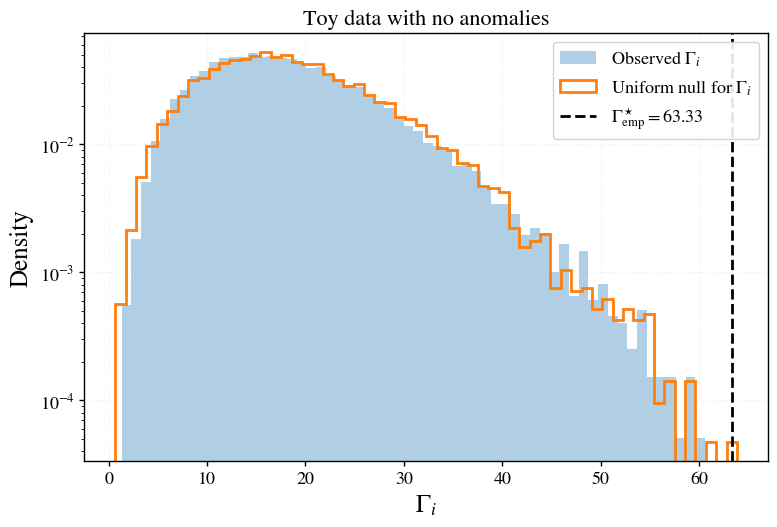

In [ ]:
import matplotlib.pyplot as plt

def set_pub_style(use_tex=False, fontsize=13):
    plt.rcParams.update({
        "font.size": fontsize,
        "axes.labelsize": fontsize,
        "axes.titlesize": fontsize + 2,
        "legend.fontsize": fontsize - 1,
        "xtick.labelsize": fontsize - 1,
        "ytick.labelsize": fontsize - 1,
        "axes.linewidth": 1.0,
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,
        "mathtext.fontset": "stix",
        "font.family": "STIXGeneral",
        "text.usetex": use_tex,
    })

set_pub_style(use_tex=False, fontsize=14)

fig, ax = plt.subplots(figsize=(8, 5.5))

# Observed Gamma_i
ax.hist(
    Gamma_i,
    bins=60,
    density=True,
    histtype="stepfilled",
    alpha=0.35,
    linewidth=1.2,
    label=r"Observed $\Gamma_i$",
)


Gamma_null_1d = flatten_gamma_null(Gamma_null_mat)
# Uniform null
ax.hist(
    Gamma_null_1d,
    bins=60,
    density=True,
    histtype="step",
    linewidth=2.0,
    label=r"Uniform null for $\Gamma_i$",
)

# Threshold

alpha_pt = p_ext
Gamma_star_emp = np.quantile(Gamma_null_1d, 1 - alpha_pt)
ax.axvline(
    Gamma_star_emp,
    color="black",
    linestyle="--",
    linewidth=2,
    label=rf"$\Gamma^\star_{{\rm emp}}={Gamma_star_emp:.2f}$",
)

ax.set_yscale("log")
ax.set_xlabel(r"$\Gamma_i$",fontweight='bold',fontsize=18)
ax.set_ylabel(r"Density",fontsize=18)
ax.set_title(r"Toy data with no anomalies")
ax.legend(frameon=True, fancybox=True, framealpha=0.9,loc='upper right')
ax.grid(alpha=0.2, linestyle=":")
plt.tight_layout()

plt.show()


## Plots

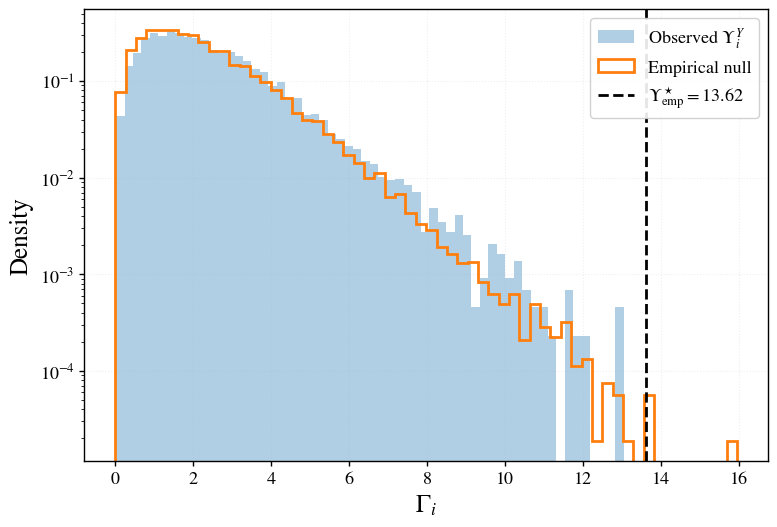

In [ ]:
import matplotlib.pyplot as plt

def set_pub_style(use_tex=False, fontsize=13):
    plt.rcParams.update({
        "font.size": fontsize,
        "axes.labelsize": fontsize,
        "axes.titlesize": fontsize + 2,
        "legend.fontsize": fontsize - 1,
        "xtick.labelsize": fontsize - 1,
        "ytick.labelsize": fontsize - 1,
        "axes.linewidth": 1.0,
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,
        "mathtext.fontset": "stix",
        "font.family": "STIXGeneral",
        "text.usetex": use_tex,
    })

set_pub_style(use_tex=False, fontsize=14)

fig, ax = plt.subplots(figsize=(8, 5.5))

# Observed Gamma_i
j = 0
ax.hist(
    result_dicts[j]['Upsilon_i_Y'],
    bins=60,
    density=True,
    histtype="stepfilled",
    alpha=0.35,
    linewidth=1.2,
    label=r"Observed $\Upsilon_i^Y$",
)

Gamma_null_1d = result_dicts[j]['stats_null'][p_list[j]]


# Uniform null
ax.hist(
    Gamma_null_1d,
    bins=60,
    density=True,
    histtype="step",
    linewidth=2.0,
    label=r"Empirical null",
)

# Threshold

alpha_pt = p_ext
Gamma_star_emp = np.quantile(Gamma_null_1d, 1 - alpha_pt)
ax.axvline(
    Gamma_star_emp,
    color="black",
    linestyle="--",
    linewidth=2,
    label=rf"$\Upsilon^\star_{{\rm emp}}={Gamma_star_emp:.2f}$",
)

ax.set_yscale("log")
ax.set_xlabel(r"$\Gamma_i$",fontweight='bold',fontsize=18)
ax.set_ylabel(r"Density",fontsize=18)
ax.legend(frameon=True, fancybox=True, framealpha=0.9,loc='upper right')
ax.grid(alpha=0.2, linestyle=":")
plt.tight_layout()

plt.show()


In [ ]:
import numpy as np

import matplotlib.pyplot as plt

# Inject anomaly into Y: add 500 points from a shifted Gaussian
Y_anomaly = Y.copy()
n_anomaly = 100
anomaly_mean = np.array([0,0,0,0])  # Shifted mean for anomaly
anomaly_cov = np.eye(4)*0.01  # Same covariance
rng = np.random.default_rng(42)
anomalous_points = rng.multivariate_normal(anomaly_mean, anomaly_cov, size=n_anomaly)
# Replace random points in Y with anomalous ones
idx_anomaly = rng.choice(len(Y), n_anomaly, replace=False)
Y_anomaly[idx_anomaly] = anomalous_points

# Use only one reference (e.g., the first one)
j_ref = 0
X_ref_single = [X_refs[j_ref]]
p_single = len(Y_anomaly) / (len(Y_anomaly) + len(X_ref_single[0]))

# Compute null for this single reference
stats_null_single = compute_the_null_multi_refs(
    p_list=[p_single],
    K_M=kM,
    N=200000,
    n_jobs=8
)

# Run EagleEye on the anomalous Y with single reference
out_anomaly = compute_Gamma_i_multi_ref_with_SrootB(
    X_refs=X_ref_single,
    Y=Y_anomaly,
    stats_null_multi=stats_null_single,
    K_M=kM,
    p_ext=p_ext,
    n_jobs=100,
    Z=2.65,
    upsilon_key="Upsilon_i_Y"
)


In [ ]:

# Now plot the data: scatter plots of Y (first two dimensions) with and without anomaly
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original Y
axes[0].scatter(Y[:, 0], Y[:, 1], alpha=0.5, s=1, label='Original Y')
axes[0].set_title('Original Data (Y)')
axes[0].set_xlabel('Feature 0')
axes[0].set_ylabel('Feature 1')
axes[0].legend()

# Anomalous Y
axes[1].scatter(Y_anomaly[:, 0], Y_anomaly[:, 1], alpha=0.5, s=1, label='Y with Anomaly')
axes[1].scatter(anomalous_points[:, 0], anomalous_points[:, 1], alpha=0.8, s=5, color='red', label='Anomalous Points')
axes[1].set_title('Data with Injected Anomaly (Y_anomaly)')
axes[1].set_xlabel('Feature 0')
axes[1].set_ylabel('Feature 1')
axes[1].legend()

plt.tight_layout()
plt.show()

# Also plot histograms of Upsilon_i_Y for the reference with and without anomaly
fig, ax = plt.subplots(figsize=(8, 5.5))

# # Original
# ax.hist(
#     result_dicts[j_ref]['Upsilon_i_Y'],
#     bins=60,
#     density=True,
#     histtype="stepfilled",
#     alpha=0.35,
#     linewidth=1.2,
#     label=r"Original $\Upsilon_i^Y$",
# )


# Null

# Anomalous
ax.hist(
    out_anomaly['result_dicts'][0]['Upsilon_i_Y'],
    bins=60,
    density=True,
    histtype="stepfilled",
    alpha=0.35,
    linewidth=1.2,
    label=r"Observed $\Upsilon_i^Y$",
)

Gamma_null_1d_single = stats_null_single["by_ref"][0]["stats_null"][p_single]
ax.hist(
    Gamma_null_1d_single,
    bins=60,
    density=True,
    histtype="step",
    linewidth=2.0,
    label=r"Empirical null",
)

# Threshold
Gamma_star_emp_single = np.quantile(Gamma_null_1d_single, 1 - p_ext)
ax.axvline(
    Gamma_star_emp_single,
    color="black",
    linestyle="--",
    linewidth=2,
    label=rf"$\Upsilon^\star_{{\rm emp}}={Gamma_star_emp_single:.2f}$",
)

ax.set_yscale("log")
ax.set_xlabel(r"$\Upsilon_i^Y$", fontweight='bold', fontsize=18)
ax.set_ylabel(r"Density", fontsize=18)
ax.set_title(r"Single Reference: Original vs Anomalous")
ax.legend(frameon=True, fancybox=True, framealpha=0.9, loc='upper right')
ax.grid(alpha=0.2, linestyle=":")
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined